## A2.4 Right-Skewed Session Duration

**Given:** mean = 4.2 minutes, median = 2.1 minutes

**Theoretical answer**

This is a **right-skewed distribution** because most users spend a short time on the platform, while a small number of highly engaged users spend much longer. These long sessions pull the mean upward, which is why the mean is greater than the median.

In e-commerce, this happens because:
- many users bounce quickly
- some users browse multiple products, compare prices, or read reviews for a long time
- a small number of heavy shoppers generate long-tail session durations

To define 'engaged users', I would prefer the **median** over the mean because the median is more robust to outliers.

For XGBoost, I would transform this feature using **log(1 + x)** to reduce skewness and compress large values. This makes the feature distribution more stable while preserving ordering.

Mean session duration: 4.02
Median session duration: 2.88
Skewness: 1.45


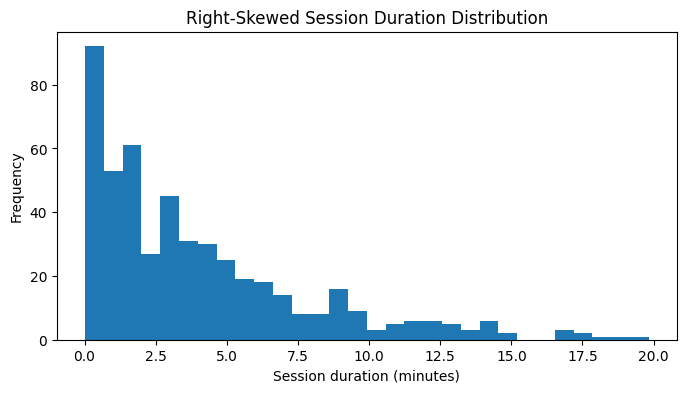

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulated right-skewed session durations (minutes)
np.random.seed(42)
session_duration = np.random.exponential(scale=4.0, size=500)
session_series = pd.Series(session_duration)

print('Mean session duration:', round(session_series.mean(), 2))
print('Median session duration:', round(session_series.median(), 2))
print('Skewness:', round(session_series.skew(), 2))

plt.figure(figsize=(8, 4))
plt.hist(session_series, bins=30)
plt.title('Right-Skewed Session Duration Distribution')
plt.xlabel('Session duration (minutes)')
plt.ylabel('Frequency')
plt.show()


Mean after log transform: 1.33
Median after log transform: 1.36
Skewness after log transform: 0.1


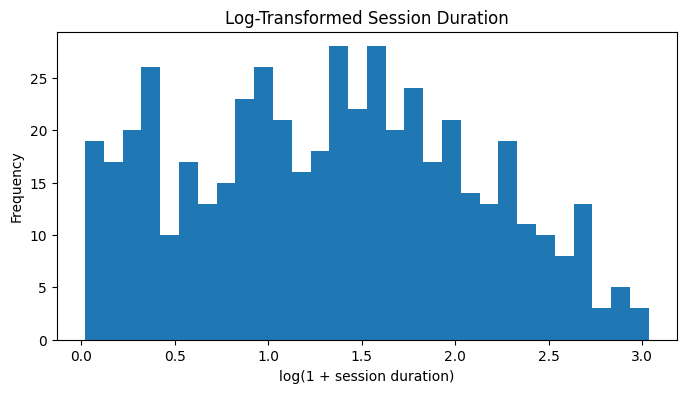

In [2]:
session_duration_log = np.log1p(session_series)

print('Mean after log transform:', round(session_duration_log.mean(), 2))
print('Median after log transform:', round(session_duration_log.median(), 2))
print('Skewness after log transform:', round(session_duration_log.skew(), 2))

plt.figure(figsize=(8, 4))
plt.hist(session_duration_log, bins=30)
plt.title('Log-Transformed Session Duration')
plt.xlabel('log(1 + session duration)')
plt.ylabel('Frequency')
plt.show()


**Interpretation**

The log transformation reduces skewness and makes the feature more suitable for modeling. Although XGBoost can handle non-linear relationships well, using a less skewed feature can still improve stability and interpretability.

## A2.5 Hypothesis Test for A/B Testing

**Given:**
- Old CTR = 3.2% with $n = 50{,}000$
- New CTR = 4.1% with $n = 50{,}000$

**Theoretical answer**

I would use a **two-proportion z-test** because CTR is a proportion and the sample sizes are large.

Define the hypotheses:
- **Null hypothesis ($H_0$):** the new system does not improve CTR, so $p_{new} = p_{old}$
- **Alternative hypothesis ($H_1$):** the new system improves CTR, so $p_{new} > p_{old}$

I would use a significance threshold of **0.05** because it is the standard choice for balancing false positives and sensitivity. If the p-value is below 0.05, I would reject the null hypothesis and conclude that the new AI recommender significantly improves CTR.

In [ ]:
import math

ctr_old = 0.032
ctr_new = 0.041
n_old = 50000
n_new = 50000

clicks_old = int(ctr_old * n_old)
clicks_new = int(ctr_new * n_new)

p_pool = (clicks_old + clicks_new) / (n_old + n_new)
standard_error = math.sqrt(p_pool * (1 - p_pool) * ((1 / n_old) + (1 / n_new)))
z_score = (ctr_new - ctr_old) / standard_error

# One-sided p-value using standard normal CDF via erf
cdf = 0.5 * (1 + math.erf(z_score / math.sqrt(2)))
p_value_one_sided = 1 - cdf

print('Old clicks:', clicks_old)
print('New clicks:', clicks_new)
print('Pooled probability:', round(p_pool, 6))
print('Standard error:', round(standard_error, 6))
print('Z-score:', round(z_score, 4))
print('One-sided p-value:', p_value_one_sided)

Old clicks: 1600
New clicks: 2050
Pooled probability: 0.0365
Standard error: 0.001186
Z-score: 7.5882
One-sided p-value: 1.6209256159527285e-14


**Interpretation**

If the p-value is very small, the observed CTR improvement is unlikely to be due to random chance. That means the new recommendation system provides a statistically significant uplift in CTR.

**Metric to emphasize:** CTR is the core business metric here because it directly measures whether recommendations are generating more clicks.

## One-tailed vs Two-tailed: Which to use for CTR A/B testing?

A two-tailed test asks: "Is the new CTR *different* from the old CTR (higher OR lower)?"
A one-tailed test asks: "Is the new CTR *better* than the old CTR (higher only)?"

For this A/B test, a one-tailed test is correct because:
- We only care if the new AI system *improves* CTR — a drop is equally
  unacceptable either way and would lead to the same decision: reject the new system.
- We have a directional hypothesis before running the test: the AI recommender
  is expected to increase CTR, not just change it.
- One-tailed tests are more statistically powerful for the same sample size —
  they require a smaller effect to reach significance, which matters when
  running expensive large-scale A/B tests.

Null hypothesis (H₀):      p_new <= p_old  (new system does not improve CTR)
Alternative hypothesis (H₁): p_new > p_old  (new system improves CTR)

We reject H₀ if p-value < 0.05, concluding the improvement is statistically
significant. The entire rejection region sits in the right tail, making the
test more sensitive to the improvement we care about.

In [1]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Observed data
n = 50_000
ctr_old = 0.032
ctr_new = 0.041

count_old = int(ctr_old * n)
count_new = int(ctr_new * n)

# One-tailed z-test (alternative='larger': new > old)
counts = np.array([count_new, count_old])
nobs   = np.array([n, n])

z_stat, p_value_one = proportions_ztest(counts, nobs, alternative='larger')
_, p_value_two      = proportions_ztest(counts, nobs, alternative='two-sided')

print(f"Z-statistic       : {z_stat:.4f}")
print(f"P-value (one-tail): {p_value_one:.6f}")
print(f"P-value (two-tail): {p_value_two:.6f}")
print()

alpha = 0.05
if p_value_one < alpha:
    print(f"Result: Reject H₀ (p={p_value_one:.4f} < {alpha})")
    print("The new AI recommender significantly improves CTR.")
    print(f"One-tailed is more powerful here — two-tailed p={p_value_two:.4f} "
          f"{'also rejects' if p_value_two < alpha else 'would NOT reject'} H₀.")
else:
    print(f"Result: Fail to reject H₀ (p={p_value_one:.4f} >= {alpha})")

Z-statistic       : 7.5882
P-value (one-tail): 0.000000
P-value (two-tail): 0.000000

Result: Reject H₀ (p=0.0000 < 0.05)
The new AI recommender significantly improves CTR.
One-tailed is more powerful here — two-tailed p=0.0000 also rejects H₀.
